# Tugas - 8 Clustering menggunakan Fuzzy C Means

NAMA : Mohammad Hasan Basri

NIM  : 210411100169

MATA KULIAH : Pencarian dan Penambangan Web - A

**Analisis kembali komponen dengan mengurangi sedikit demi sedikit, lalu pilih yang terbaik, kemudian tampilkan dalam grafik scater plot lalu di deploy**


In [27]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas_PPWA/Hasil_Preprocessing_Hasan_encoded.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal,kategori_encoded
0,Iran Serukan Negara Muslim Bersatu Hentikan Ke...,"Kamis, 17 Okt 2024 10:01 WIB",Jakarta - Presiden Iran Masoud Pezeshkian mene...,Keislaman,Jakarta Presiden Iran Masoud Pezeshkian menek...,jakarta presiden iran masoud pezeshkian menek...,"['jakarta', 'presiden', 'iran', 'masoud', 'pez...",jakarta presiden iran masoud pezeshkian meneka...,0
1,"Bacaan Al-Qur'an Surah Asy-Syu'ara: Arab, Lati...","Kamis, 17 Okt 2024 09:30 WIB",NaN,Keislaman,NaN,NaN,['nan'],NaN,0
2,"Rukun Iman Ke-2, Setiap Muslim Wajib Mengimani...","Kamis, 17 Okt 2024 08:45 WIB",Jakarta - Malaikat adalah makhluk ciptaan Alla...,Keislaman,Jakarta Malaikat adalah makhluk ciptaan Allah...,jakarta malaikat adalah makhluk ciptaan allah...,"['jakarta', 'malaikat', 'adalah', 'makhluk', '...",jakarta malaikat makhluk ciptaan allah swt mus...,0
3,Kalender Ramadhan 2025 Muhammadiyah dan Predik...,"Kamis, 17 Okt 2024 08:00 WIB",Jakarta - Kalender Ramadhan 2025 versi Muhamma...,Keislaman,Jakarta Kalender Ramadhan versi Muhammadiyah...,jakarta kalender ramadhan versi muhammadiyah...,"['jakarta', 'kalender', 'ramadhan', 'versi', '...",jakarta kalender ramadhan versi muhammadiyah t...,0
4,20 Gambaran Kehidupan di Neraka Menurut Al-Qur...,"Kamis, 17 Okt 2024 07:15 WIB",Jakarta - Gambaran kehidupan di neraka selalu ...,Keislaman,Jakarta Gambaran kehidupan di neraka selalu m...,jakarta gambaran kehidupan di neraka selalu m...,"['jakarta', 'gambaran', 'kehidupan', 'di', 'ne...",jakarta gambaran kehidupan neraka pengingat ke...,0


In [30]:
# Map categories to encoded values
category_mapping = {
    'Keislaman': 0,
    'Pariwisata': 1
}

df['kategori_encoded'] = df['kategori'].map(category_mapping)

# Save the updated dataset
output_file_path = 'kategori_encoded_data_updated.csv'
df.to_csv(output_file_path, index=False)

print(f"File berhasil diperbarui dan dapat diunduh di tautan berikut:")
output_file_path

File berhasil diperbarui dan dapat diunduh di tautan berikut:


'kategori_encoded_data_updated.csv'

In [31]:
texts = df['stopword_removal']

In [32]:
# Replace NaN values with an empty string
texts = texts.fillna('')

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [33]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 6772)

In [34]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori_encoded']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, epsilon=0.001, random_state=42)
    #m= jarak kedekatan antara cluster
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.9582827821510551, ARI=0.0, NMI=0.018639764244343528
Iterasi dengan n_components=3: Silhouette=0.9330469855063613, ARI=0.002427096100870114, NMI=0.0513556720154113
Iterasi dengan n_components=4: Silhouette=0.9103311404986927, ARI=0.00485601903559462, NMI=0.06633317724023008
Iterasi dengan n_components=5: Silhouette=0.9064684650676645, ARI=0.008096346523631212, NMI=0.08068918390116896
Iterasi dengan n_components=6: Silhouette=0.8735346041359235, ARI=0.012148896880163282, NMI=0.09456435533426642
Iterasi dengan n_components=7: Silhouette=0.859460815010821, ARI=0.01701445012943135, NMI=0.10806496399729751
Iterasi dengan n_components=8: Silhouette=0.842584349739052, ARI=0.02269374787246114, NMI=0.1212746751286823
Iterasi dengan n_components=9: Silhouette=0.818910992475677, ARI=0.02918749315918129, NMI=0.13426149725450204
Iterasi dengan n_components=10: Silhouette=0.7716537743259763, ARI=0.0364963503649635, NMI=0.14708219223672478
Iterasi dengan n_c

In [35]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.9582827821510551
Best ARI is achieved by n_components=23 with score: 0.28521458361361496
Best NMI is achieved by n_components=23 with score: 0.27753402924773746


In [36]:
# Mengurutkan hasil berdasarkan silhouette score (dari tertinggi ke terendah)
sorted_results = sorted(results.items(), key=lambda x: x[1]['silhouette'], reverse=True)

# Menampilkan hasil akhir
print(f"\nBest n_components: {best_n_components} with silhouette score: {best_silhouette}")
print("\nAll results (sorted by silhouette score):")
for n, score in sorted_results:
    print(f"n_components={n}: Silhouette Score={score}")


Best n_components: 2 with silhouette score: 0.9582827821510551

All results (sorted by silhouette score):
n_components=2: Silhouette Score={'silhouette': 0.9582827821510551, 'ari': 0.0, 'nmi': 0.018639764244343528}
n_components=3: Silhouette Score={'silhouette': 0.9330469855063613, 'ari': 0.002427096100870114, 'nmi': 0.0513556720154113}
n_components=4: Silhouette Score={'silhouette': 0.9103311404986927, 'ari': 0.00485601903559462, 'nmi': 0.06633317724023008}
n_components=5: Silhouette Score={'silhouette': 0.9064684650676645, 'ari': 0.008096346523631212, 'nmi': 0.08068918390116896}
n_components=6: Silhouette Score={'silhouette': 0.8735346041359235, 'ari': 0.012148896880163282, 'nmi': 0.09456435533426642}
n_components=7: Silhouette Score={'silhouette': 0.859460815010821, 'ari': 0.01701445012943135, 'nmi': 0.10806496399729751}
n_components=8: Silhouette Score={'silhouette': 0.842584349739052, 'ari': 0.02269374787246114, 'nmi': 0.1212746751286823}
n_components=9: Silhouette Score={'silhou

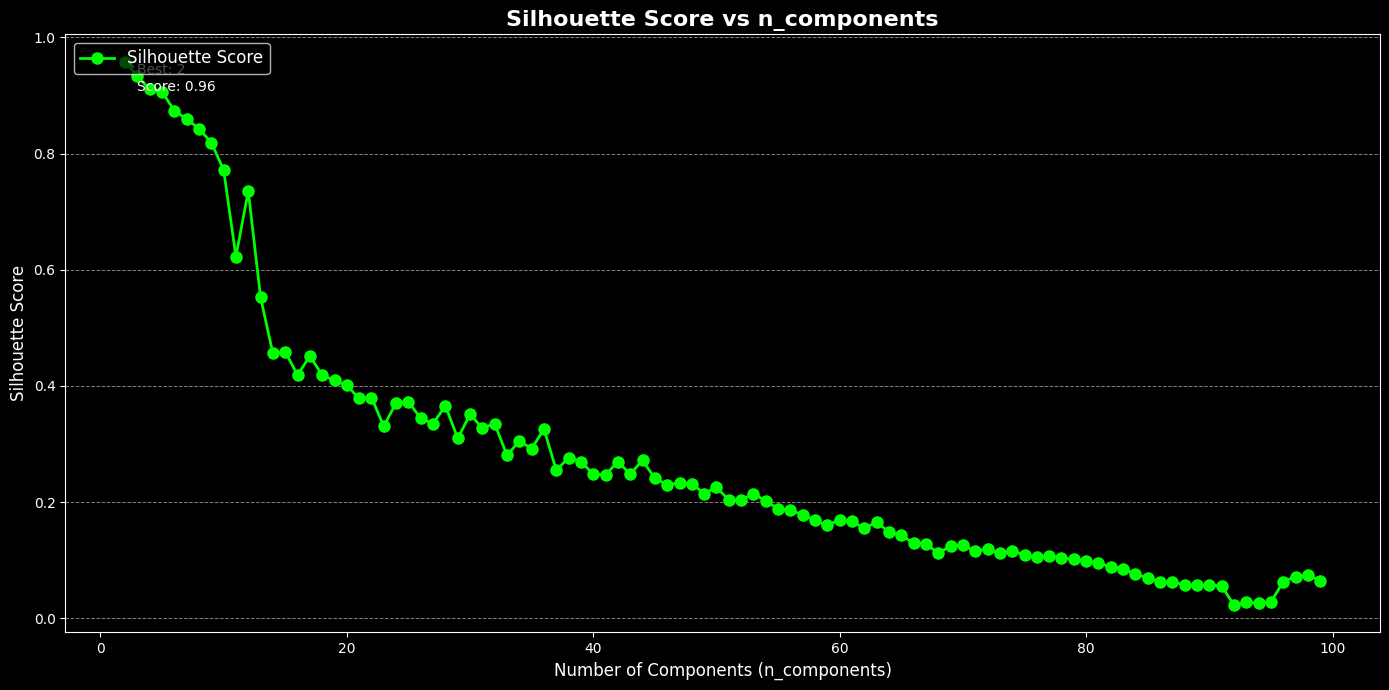

In [37]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Clustering

Silhouette Score: 0.3258
Jumlah data pada setiap cluster:
Cluster
1    68
0    32
Name: count, dtype: int64


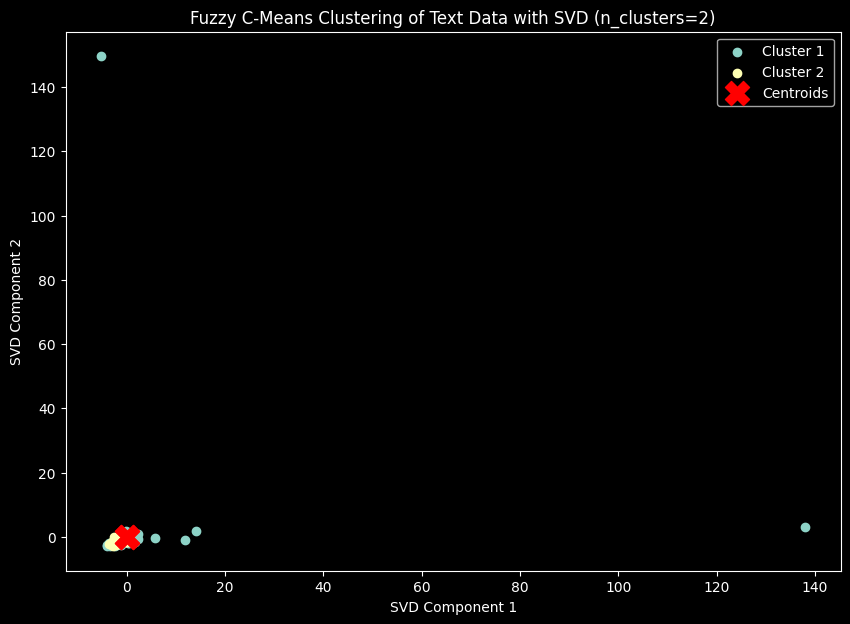

In [38]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas_PPWA/Hasil_Preprocessing_Hasan_encoded.csv")
data = df['stopword_removal']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=36 , random_state=random_seed)
#merubah n_components=
data_cluster = svd.fit_transform(data_normalisasi)

#fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.001, random_state=42) parameter

# Fuzzy C-Means Clustering
n_clusters = 2
#fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.001, random_state=42)
fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.001, random_state=42)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 1],
                data_cluster[cluster_labels == i, 0], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:, 1], cluster_centers[:, 0], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [39]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal,kategori_encoded,Cluster
0,Iran Serukan Negara Muslim Bersatu Hentikan Ke...,"Kamis, 17 Okt 2024 10:01 WIB",Jakarta - Presiden Iran Masoud Pezeshkian mene...,Keislaman,Jakarta Presiden Iran Masoud Pezeshkian menek...,jakarta presiden iran masoud pezeshkian menek...,"['jakarta', 'presiden', 'iran', 'masoud', 'pez...",jakarta presiden iran masoud pezeshkian meneka...,0,1
1,"Bacaan Al-Qur'an Surah Asy-Syu'ara: Arab, Lati...","Kamis, 17 Okt 2024 09:30 WIB",NaN,Keislaman,NaN,NaN,['nan'],NaN,0,1
2,"Rukun Iman Ke-2, Setiap Muslim Wajib Mengimani...","Kamis, 17 Okt 2024 08:45 WIB",Jakarta - Malaikat adalah makhluk ciptaan Alla...,Keislaman,Jakarta Malaikat adalah makhluk ciptaan Allah...,jakarta malaikat adalah makhluk ciptaan allah...,"['jakarta', 'malaikat', 'adalah', 'makhluk', '...",jakarta malaikat makhluk ciptaan allah swt mus...,0,0
3,Kalender Ramadhan 2025 Muhammadiyah dan Predik...,"Kamis, 17 Okt 2024 08:00 WIB",Jakarta - Kalender Ramadhan 2025 versi Muhamma...,Keislaman,Jakarta Kalender Ramadhan versi Muhammadiyah...,jakarta kalender ramadhan versi muhammadiyah...,"['jakarta', 'kalender', 'ramadhan', 'versi', '...",jakarta kalender ramadhan versi muhammadiyah t...,0,1
4,20 Gambaran Kehidupan di Neraka Menurut Al-Qur...,"Kamis, 17 Okt 2024 07:15 WIB",Jakarta - Gambaran kehidupan di neraka selalu ...,Keislaman,Jakarta Gambaran kehidupan di neraka selalu m...,jakarta gambaran kehidupan di neraka selalu m...,"['jakarta', 'gambaran', 'kehidupan', 'di', 'ne...",jakarta gambaran kehidupan neraka pengingat ke...,0,0
...,...,...,...,...,...,...,...,...,...,...
95,"Praha Incar Turis-Turis Kaya, 'Wisata Pub Jala...","Rabu, 16 Okt 2024 06:13 WIB",Praha - Praha ingin mengganti imej dari kota s...,Pariwisata,Praha Praha ingin mengganti imej dari kota se...,praha praha ingin mengganti imej dari kota se...,"['praha', 'praha', 'ingin', 'mengganti', 'imej...",praha praha mengganti imej kota tujuan wisata ...,1,1
96,"Usai Festival Vegetarian, Phuket Pusing dengan...","Rabu, 16 Okt 2024 05:39 WIB",Phuket - Festival Vegetarian menjadi salah sat...,Pariwisata,Phuket Festival Vegetarian menjadi salah satu...,phuket festival vegetarian menjadi salah satu...,"['phuket', 'festival', 'vegetarian', 'menjadi'...",phuket festival vegetarian salah daya tarik pa...,1,1
97,Ngeri! Turis Inggris Tewas Saat Memanjat Jemba...,"Rabu, 16 Okt 2024 05:01 WIB",Jakarta - Seorang turis yang juga kreator kont...,Pariwisata,Jakarta Seorang turis yang juga kreator konte...,jakarta seorang turis yang juga kreator konte...,"['jakarta', 'seorang', 'turis', 'yang', 'juga'...",jakarta turis kreator konten inggris berusia t...,1,1
98,Info Loker: Lion Group Buka Lowongan Mekanik Nih!,"Selasa, 15 Okt 2024 23:04 WIB",Jakarta - Traveler yang ingin bekerja di dunia...,Pariwisata,Jakarta Traveler yang ingin bekerja di dunia ...,jakarta traveler yang ingin bekerja di dunia ...,"['jakarta', 'traveler', 'yang', 'ingin', 'beke...",jakarta traveler dunia aviasi baiknya simak in...,1,1


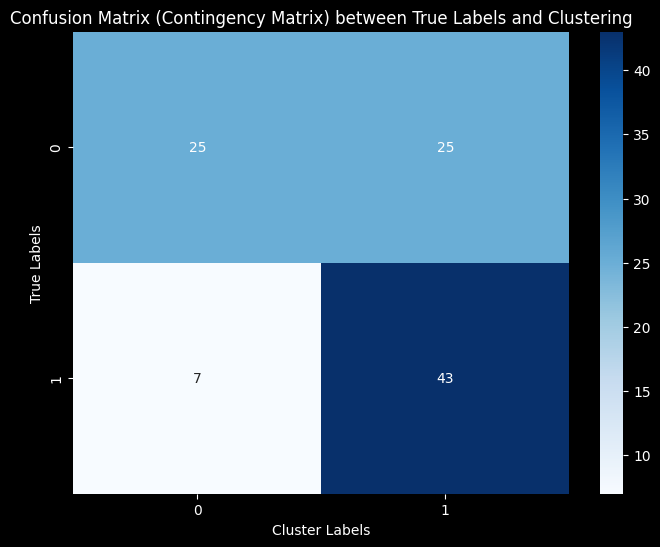

Confusion Matrix (Contingency Matrix):
[[25 25]
 [ 7 43]]


In [40]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori_encoded']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [41]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori_encoded, dan Cluster
selected_columns = df[['id', 'kategori_encoded', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

    id  kategori_encoded  Cluster
0    0                 0        1
1    1                 0        1
2    2                 0        0
3    3                 0        1
4    4                 0        0
..  ..               ...      ...
95  95                 1        1
96  96                 1        1
97  97                 1        1
98  98                 1        1
99  99                 1        0

[100 rows x 3 columns]
Anggota Cluster 0: [2, 4, 6, 7, 8, 9, 10, 12, 15, 16, 20, 22, 24, 25, 26, 28, 29, 30, 33, 35, 37, 39, 41, 42, 44, 50, 68, 71, 76, 80, 94, 99]
Anggota Cluster 1: [0, 1, 3, 5, 11, 13, 14, 17, 18, 19, 21, 23, 27, 31, 32, 34, 36, 38, 40, 43, 45, 46, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 69, 70, 72, 73, 74, 75, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 98]


In [42]:
from sklearn.metrics import silhouette_score
import numpy as np

# Mengonversi keanggotaan fuzzy menjadi label cluster dengan memilih cluster dengan membership tertinggi
fuzzy_labels = np.argmax(membership, axis=1)

# Menghitung Silhouette Score
silhouette_avg = silhouette_score(data_cluster, fuzzy_labels)

# Menampilkan Silhouette Score
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.3258


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import joblib
import pandas as pd

# Membaca data
df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas_PPWA/Hasil_Preprocessing_Hasan_encoded.csv")
data = df['stopword_removal'].astype(str)  # Pastikan data berupa string

# Fungsi untuk menerapkan FCM dalam pipeline
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,         # Jumlah cluster yang diinginkan
        m=2.0,                # Fuzziness coefficient
        max_iter=1000,        # Maksimal iterasi
        epsilon=0.001,        # Toleransi konvergensi
        random_state=42       # Menetapkan seed untuk random state
    )
    fcm.fit(X)
    return fcm

# Fungsi pembungkus untuk FCM (untuk FunctionTransformer)
def fit_fcm_wrapper(X):
    return fit_fcm(X)

# Tuning parameter TfidfVectorizer
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))),
    ('scaler', StandardScaler(with_mean=False)),
    ('svd', TruncatedSVD(n_components=20)),
    ('fcm', FunctionTransformer(func=fit_fcm_wrapper))
])

# Fit pipeline pada data pelatihan
pipeline.fit(data)

# Simpan pipeline yang telah dilatih
joblib.dump(pipeline, 'svd_tfidf_scaler_fcm_pipeline.pkl')

['svd_tfidf_scaler_fcm_pipeline.pkl']

In [44]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import numpy as np
import pandas as pd

# 1. Memuat pipeline yang sudah dilatih sebelumnya
pipeline = joblib.load('svd_tfidf_scaler_fcm_pipeline.pkl')

# 2. Melakukan FCM pada data pelatihan (sudah dilabeli Games dan Sepakbola)
df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas_PPWA/Hasil_Preprocessing_Hasan_encoded.csv")
# Replace NaN values with an empty string before transforming
data_pelatihan = df['stopword_removal'].fillna('').astype(str)

# Transformasi data pelatihan menggunakan pipeline
X_train_transformed = pipeline[:-1].transform(data_pelatihan)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

# 3. Melakukan clustering FCM pada data pelatihan
fcm_model = FCM(n_clusters=2, m=2.0, max_iter=1000, epsilon=0.001, random_state=42)
fcm_model.fit(X_train_transformed)

# 4. Menyelaraskan cluster dengan label yang diketahui
labels_train = df['kategori_encoded']

# Menyelaraskan cluster dengan label
cluster_labels = fcm_model.predict(X_train_transformed)
cluster_to_label = {0: 'Keislaman', 1: 'Pariwisata'} #0: 'Otomotif', 1: 'Keuangan' dan #0: 'Keuangan', 1: 'Otomotif'

# Menyelaraskan prediksi cluster dengan label
predicted_labels = [cluster_to_label[cluster] for cluster in cluster_labels]

# 5. Memuat data baru untuk prediksi
teks_baru = """Jakarta  Mimpi buruk adalah hal yang lumrah terjadi dan tidak bisa dihindari manusia Mimpi buruk membuat yang mengalaminya merasakan cemas dan takut yang berlebihan Islam merupakan agama yang sempurna dan selalu mendahulukan setiap aktivitas dengan berdoa Agar terhindar dari mimpi buruk ada doa dan amalan yang bisa dilakukan umat Islam Rasulullah SAW telah memberikan teladan kepada umatnya tentang cara menghindari mimpi buruk Rasulullah SAW bersabda Apabila seorang dari kalian bermimpi yang ia sukai berarti itu dari Allah dan hendaknya dia mengucapkan hamdalah karenanya serta menceritakannya Tapi bila dia mendapat mimpi yang tidak disukai berarti itu dari setan maka hendaklah dia berlindung dari kejahatannya dan jangan menceritakannya kepada siapapun niscaya hal itu tidak akan berdampak buruk baginya HR AlBukhari Dari hadits di atas jika kita bermimpi yang menyenangkan hendaknya memuji Allah SWT dan boleh menceritakannya karena mimpi yang baik itu akan menjadi kenyataan Sebaliknya hendaknya kita tidak memberitahukan mimpi buruk kepada orang lain dan memohon perlindungan kepada Allah dari gangguan setan Doa agar Tidak Mimpi Buruk Berikut ini beberapa doa yang dapat diamalkan agar tidak bermimpi buruk Doa agar Tidak Mimpi Buruk  Mengutip dari buku Tuntunan Doa dan Dzikir untuk Segala Situasi dan Kebutuhan karya Ali Akbar bin Aqil berikut adalah doa yang dimaksud          Bacaan latin Allohumma inniazubika min amalis syaithoni wa sayyiatil ahlam Artinya Ya Allah aku berlindung kepadaMu dari perbuatan setan dan buruknya mimpi Doa agar Tidak Mimpi Buruk  Masih menukil dari buku yang sama seperti sebelumnya berikut doa agar tidak mimpi buruk versi                     Bacaan latin Auudzu bikalimaatillaahittaammaati minghodhobihi wa iqoobihi wasyarri ibaadihi wamin hamazaatisysyayaathiini wa an yahdhuruu wa min hamajaatisysyayaatiini wa an yahduruun Artinya Aku berlindung dengan kalimat Allah yang sempurna dari kemarahan dan siksaanNya serta kejahatan hambahambaNya dan dari godaan setan bisikannya serta jangan sampai mereka hadir kepadaku  Doa Mengharap Mimpi Baik Menukil buku Tiket ke Surga DoaDoa Mustajab karya Abdul Majid dan Isfaudin berikut doa mengharap mimpi baik            Bacaan latin Allahumma arinal haqqa haqqan warzuqnat tibaaahu Wa arinal baathila baathilan warzuqnajtina bahu Artinya Ya Allah tunjukkanlah kepada kami kebenaran sehingga kami bisa mengikutinya dan tunjukkanlah kepada kami kejelekan sehingga kami dapat menjauhinya Amalan Sebelum Tidur Agar tidak mimpi buruk ada amalan yang dapat umat Islam kerjakan sebelum tidur Berikut ini amalanamalannya yang dikerjakan Rasulullah sebelum tidur dikutip dari buku Sunnah Rasulullah SehariHari karya Syaikh Abdullah bin Hamoud Al Furaih  Wudhu Sebelum Tidur Wudhu merupakan salah satu amalan sunnah yang dicontohkan Rasulullah sebelum tidur Hal tersebut sebagaimana yang termaktub dalam hadits Al Bara bin Azib Nabi Muhammad SAW bersabda             Artinya Jika hendak mendatangi tempat tidurmu berwudhulah seperti wudhu untuk sholat lalu berbaringlah ke sisi kanan badanmu HR AlBukhari no  dan Muslim no   Membaca Doa Sebelum Tidur Amalan selanjutnya adalah membaca doa sebelum tidur Hal ini termaktub dalam hadits yang diriwayatkan oleh Hudzaifah beliau berkata                                      Artinya Apabila Nabi Muhammad SAW hendak tidur beliau membaca doa Bismika allahumma amutu waahya Dengan namaMu Ya Allah aku mati dan aku hidup Dan apabila bangun tidur Beliau berdoa Alhamdulillahilladzi ahyana bada maa amatana wailaihinnusyur Segala puji bagi Allah yang telah menghidupkan kami setelah mematikan kami dan kepadaNya lah tempat kembali HR Bukhari no   Mengibas Kasur Sebelum tidur hendaknya seorang muslim mengibas kasurnya terlebih dahulu Cara ini dijelaskan dalam hadits Abu Hurairah Rasulullah SAW bersabda Jika di antara kamu ingin mendatangi tempat tidur hendaklah untuk mengibas kasurnya dengan bagian dalam sarungnya Karena ia tidak mengetahui apa yang ada padanya lalu ucapkan     Latin Bismika rabbi wadhatu janbii Artinya Dengan namaMu Wahai Tuhanku aku baringkan punggungku HR Bukhari no  dan Muslim no   Membaca Ayat Kursi Selanjutnya kaum muslim dianjurkan membaca Ayat Kursi sebelum tidur Keutamaan membaca Ayat Kursi sebelum tidur adalah mendapatkan perlindungan dari Allah SWT dari gangguan setan hingga pagi hari Diriwayatkan oleh Abu Hurairah Nabi Muhammad SAW membenarkan pernyataan berikut                       Artinya Jika kamu hendak berbaring di atas tempat tidurmu bacalah ayat Kursi Karena dengannya kamu selalu dijaga oleh Allah dan setan tidak akan dapat mendekatimu hingga pagi HR Bukhari  Dianjurkan untuk Menunda Tidur Sebelum Isya Rasulullah SAW mencontohkan agar tidak tidur sebelum waktu Isya dengan maksud agar sahabat tidak melewatkan ibadah utama yakni sholat Isya Anjuran ini berdasarkan hadits yang diriwayatkan oleh Abu Barzah ia berkata Bahwa Nabi Muhammad SAW tidak suka tidur sebelum sholat Isya dan berbincangbincang setelahnya HR Bukhari no  dan Muslim no   Berbaring Miring ke Kanan Amalan terakhir yang dilakukan Rasulullah SAW sebelum tidur adalah berbaring miring ke kanan Ketika hendak tidur Rasulullah SAW akan berbaring di sisi kanannya dan mengucapkan Ya Allah Aku telah menyerahkan diriku kepadaMu dan mempercayakan urusanku kepadaMu Dan aku memalingkan wajahku kepadaMu mengharapkan pahalaMu dan takut hukumanMu dan mengandalkanMu Tidak mungkin lari dariMu dan berlindung pada orang lain kami berlindung hanya padaMu Aku percaya pada Kitab yang Engkau turunkan dan Nabi yang Engkau kirim HR Bukhari hnhkri"""

#contohberitaKeislaman: Jakarta  Mimpi buruk adalah hal yang lumrah terjadi dan tidak bisa dihindari manusia Mimpi buruk membuat yang mengalaminya merasakan cemas dan takut yang berlebihan Islam merupakan agama yang sempurna dan selalu mendahulukan setiap aktivitas dengan berdoa Agar terhindar dari mimpi buruk ada doa dan amalan yang bisa dilakukan umat Islam Rasulullah SAW telah memberikan teladan kepada umatnya tentang cara menghindari mimpi buruk Rasulullah SAW bersabda Apabila seorang dari kalian bermimpi yang ia sukai berarti itu dari Allah dan hendaknya dia mengucapkan hamdalah karenanya serta menceritakannya Tapi bila dia mendapat mimpi yang tidak disukai berarti itu dari setan maka hendaklah dia berlindung dari kejahatannya dan jangan menceritakannya kepada siapapun niscaya hal itu tidak akan berdampak buruk baginya HR AlBukhari Dari hadits di atas jika kita bermimpi yang menyenangkan hendaknya memuji Allah SWT dan boleh menceritakannya karena mimpi yang baik itu akan menjadi kenyataan Sebaliknya hendaknya kita tidak memberitahukan mimpi buruk kepada orang lain dan memohon perlindungan kepada Allah dari gangguan setan Doa agar Tidak Mimpi Buruk Berikut ini beberapa doa yang dapat diamalkan agar tidak bermimpi buruk Doa agar Tidak Mimpi Buruk  Mengutip dari buku Tuntunan Doa dan Dzikir untuk Segala Situasi dan Kebutuhan karya Ali Akbar bin Aqil berikut adalah doa yang dimaksud          Bacaan latin Allohumma inniazubika min amalis syaithoni wa sayyiatil ahlam Artinya Ya Allah aku berlindung kepadaMu dari perbuatan setan dan buruknya mimpi Doa agar Tidak Mimpi Buruk  Masih menukil dari buku yang sama seperti sebelumnya berikut doa agar tidak mimpi buruk versi                     Bacaan latin Auudzu bikalimaatillaahittaammaati minghodhobihi wa iqoobihi wasyarri ibaadihi wamin hamazaatisysyayaathiini wa an yahdhuruu wa min hamajaatisysyayaatiini wa an yahduruun Artinya Aku berlindung dengan kalimat Allah yang sempurna dari kemarahan dan siksaanNya serta kejahatan hambahambaNya dan dari godaan setan bisikannya serta jangan sampai mereka hadir kepadaku  Doa Mengharap Mimpi Baik Menukil buku Tiket ke Surga DoaDoa Mustajab karya Abdul Majid dan Isfaudin berikut doa mengharap mimpi baik            Bacaan latin Allahumma arinal haqqa haqqan warzuqnat tibaaahu Wa arinal baathila baathilan warzuqnajtina bahu Artinya Ya Allah tunjukkanlah kepada kami kebenaran sehingga kami bisa mengikutinya dan tunjukkanlah kepada kami kejelekan sehingga kami dapat menjauhinya Amalan Sebelum Tidur Agar tidak mimpi buruk ada amalan yang dapat umat Islam kerjakan sebelum tidur Berikut ini amalanamalannya yang dikerjakan Rasulullah sebelum tidur dikutip dari buku Sunnah Rasulullah SehariHari karya Syaikh Abdullah bin Hamoud Al Furaih  Wudhu Sebelum Tidur Wudhu merupakan salah satu amalan sunnah yang dicontohkan Rasulullah sebelum tidur Hal tersebut sebagaimana yang termaktub dalam hadits Al Bara bin Azib Nabi Muhammad SAW bersabda             Artinya Jika hendak mendatangi tempat tidurmu berwudhulah seperti wudhu untuk sholat lalu berbaringlah ke sisi kanan badanmu HR AlBukhari no  dan Muslim no   Membaca Doa Sebelum Tidur Amalan selanjutnya adalah membaca doa sebelum tidur Hal ini termaktub dalam hadits yang diriwayatkan oleh Hudzaifah beliau berkata                                      Artinya Apabila Nabi Muhammad SAW hendak tidur beliau membaca doa Bismika allahumma amutu waahya Dengan namaMu Ya Allah aku mati dan aku hidup Dan apabila bangun tidur Beliau berdoa Alhamdulillahilladzi ahyana bada maa amatana wailaihinnusyur Segala puji bagi Allah yang telah menghidupkan kami setelah mematikan kami dan kepadaNya lah tempat kembali HR Bukhari no   Mengibas Kasur Sebelum tidur hendaknya seorang muslim mengibas kasurnya terlebih dahulu Cara ini dijelaskan dalam hadits Abu Hurairah Rasulullah SAW bersabda Jika di antara kamu ingin mendatangi tempat tidur hendaklah untuk mengibas kasurnya dengan bagian dalam sarungnya Karena ia tidak mengetahui apa yang ada padanya lalu ucapkan     Latin Bismika rabbi wadhatu janbii Artinya Dengan namaMu Wahai Tuhanku aku baringkan punggungku HR Bukhari no  dan Muslim no   Membaca Ayat Kursi Selanjutnya kaum muslim dianjurkan membaca Ayat Kursi sebelum tidur Keutamaan membaca Ayat Kursi sebelum tidur adalah mendapatkan perlindungan dari Allah SWT dari gangguan setan hingga pagi hari Diriwayatkan oleh Abu Hurairah Nabi Muhammad SAW membenarkan pernyataan berikut                       Artinya Jika kamu hendak berbaring di atas tempat tidurmu bacalah ayat Kursi Karena dengannya kamu selalu dijaga oleh Allah dan setan tidak akan dapat mendekatimu hingga pagi HR Bukhari  Dianjurkan untuk Menunda Tidur Sebelum Isya Rasulullah SAW mencontohkan agar tidak tidur sebelum waktu Isya dengan maksud agar sahabat tidak melewatkan ibadah utama yakni sholat Isya Anjuran ini berdasarkan hadits yang diriwayatkan oleh Abu Barzah ia berkata Bahwa Nabi Muhammad SAW tidak suka tidur sebelum sholat Isya dan berbincangbincang setelahnya HR Bukhari no  dan Muslim no   Berbaring Miring ke Kanan Amalan terakhir yang dilakukan Rasulullah SAW sebelum tidur adalah berbaring miring ke kanan Ketika hendak tidur Rasulullah SAW akan berbaring di sisi kanannya dan mengucapkan Ya Allah Aku telah menyerahkan diriku kepadaMu dan mempercayakan urusanku kepadaMu Dan aku memalingkan wajahku kepadaMu mengharapkan pahalaMu dan takut hukumanMu dan mengandalkanMu Tidak mungkin lari dariMu dan berlindung pada orang lain kami berlindung hanya padaMu Aku percaya pada Kitab yang Engkau turunkan dan Nabi yang Engkau kirim HR Bukhari hnhkri
#contohberitaPariwisata: jakarta zaman traveling sekedar hobi gaya hidup orang tujuan liburan bisnis konteks memilih online travel agency ota perjalanan dilaksanakan sesuai rencana bookcabin hadir pilihan ota ideal program loyalitas cabinclub bookcabin memenuhi kebutuhan traveling menawarkan keuntungan pelanggannya konsep traveling healing berdasarkan data badan pusat statistik bps perjalanan wisatawan domestik mencapai juta perjalanan juli peningkatan persen dibandingkan kelas menengah generasi z indonesia menganggap traveling salah prioritas kebutuhan sekunder insight tool google healing tren traveling dicari traveler pandemi meningkatnya konsep traveling healing memilih ota kenyamanan proses persiapan perjalanan bookcabin hadir pelayanan platform aplikasi mudah kenyamanan penggunanya itinerary traveling ota bernaung lion air group menawarkan pilihan penerbangan akomodasi mudah diakses bookcabin menawarkan harga kompetitif promo menarik perjalanan hemat cabinclub membership salah keunggulan utama bookcabin program loyalitasnya cabinclub program bertujuan apresiasi anggota pemberian manfaat eksklusif pengumpulan poin pemesanan tiket bookcabin poin khusus oktober november promo khusus anggota cabinclub mendaftar aplikasi bookcabin pemesanan tiket salah maskapai lion air group lion air batik air super air jet wings air batik air malaysia thai lion poinpoin terkumpul ditukarkan merchandise menarik laptop ponsel tiket pesawat smartwatch anggota bonus poin kali kesempatan mengumpulkan poin cepat khusus mendaftar anggota cabinclub periode promo langsung poin pengguna hemat perjalanan poinpoin terkumpul pembelian tiket penerbangan kesempatan upgrade anggota cabinclub memiliki peluang upgrade kelas penerbangan biaya tambahan periode promo oktobernovember salah orang online checkin penerbangan batik air kesempatan upgrade gratis kelas ekonomi kelas bisnis layanan pelanggan prioritas anggota cabinclub disesuaikan tier masingmasing silver gold platinum pengguna akses layanan pelanggan pengalaman perjalanan lancar nyaman keterkaitan kebutuhan pilihan meningkatkan kebutuhan travelling kesadaran perjalanan berkualitas bookcabin ota menawarkan program loyalitas cabinclub pilihan program membantu traveler menghemat uang meningkatkan kualitas pengalaman perjalanan prfega

# Transformasi data baru menggunakan pipeline
X_new_transformed = pipeline[:-1].transform([teks_baru])
if hasattr(X_new_transformed, 'toarray'):
    X_new_transformed = X_new_transformed.toarray()

# 6. Prediksi cluster untuk data baru
cluster_new = fcm_model.predict(X_new_transformed)

# Menyelaraskan prediksi cluster dengan label
predicted_label_new = cluster_to_label[cluster_new[0]]

# 7. Menampilkan hasil
print(f"Teks baru ini diprediksi ke dalam cluster: {predicted_label_new}")


Teks baru ini diprediksi ke dalam cluster: Keislaman


In [45]:
from fcmeans import FCM
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import joblib

# Fungsi untuk menerapkan FCM
def fit_fcm(X):
    fcm = FCM(
        n_clusters=2,
        m=1.5,
        max_iter=1000,
        epsilon=0.0001,
        random_state=42
    )
    fcm.fit(X)
    return fcm

# Pipeline tanpa FCM
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # TF-IDF untuk teks
    ('scaler', StandardScaler(with_mean=False)),  # Normalisasi data
    ('svd', TruncatedSVD(n_components=10))  # Reduksi Dimensi
])

# Fit pipeline pada data
transformed_data = pipeline.fit_transform(data)  # Pastikan 'data' sudah diproses sebelumnya

# Jalankan FCM pada data yang sudah diproses
fcm_result = fit_fcm(transformed_data)

# Simpan pipeline dan hasil FCM dalam satu file (tuple)
joblib.dump((pipeline, fcm_result), 'fcm_pipeline.pkl')

['fcm_pipeline.pkl']